In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import anndata as ad
import pertpy as pt
import scanpy as sc
import numpy as np
import pandas as pd
import math
import seaborn as sns

sccoda_model = pt.tl.Sccoda()

In [2]:
adata_age_nk= sc.read_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_combined_annot_with_age_scvi.h5ad")

In [3]:
adata_age_nk

AnnData object with n_obs × n_vars = 187173 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in 

In [4]:
adata_age_nk.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      38395
4–6      47808
7–10     33857
11–14    50273
15–18    16840
Name: count, dtype: int64

In [5]:
adata_age_nk.obs["Age_years"].value_counts().sort_index()

Age_years
0.05     2137
0.07      969
0.14      662
0.35      709
0.48      789
         ... 
16.16    1193
16.20    1168
16.29     536
16.78    1238
17.03    1329
Name: count, Length: 122, dtype: int64

In [6]:
adata_age_nk.obs["Sex"].value_counts().sort_index()

Sex
Female     69990
Male      117183
Name: count, dtype: int64

In [7]:
adata_age_nk.obs["Age"].value_counts().sort_index()

Age
0     11205
1      5852
2      8798
3     12540
4     19388
5     14781
6     13639
7     13179
8     10308
9      6894
10     3476
11    13299
12     7505
13    12040
14    17429
15    10180
16     5331
17     1329
Name: count, dtype: int64

In [8]:
adata_age_nk.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata_age_nk.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD56_dim CD16+ NK           171221
CD56_dim CD16+ KLRC2+ NK     15081
CD56_bright CD16- NK           871
Name: count, dtype: int64

In [9]:
adata_age_nk.obs["Batch"] = adata_age_nk.obs["Batch"].astype("category")
adata_age_nk.obs["Age_years"] = adata_age_nk.obs["Age_years"].astype("float")
adata_age_nk.obs["Sex"] = adata_age_nk.obs["Sex"].astype("category")
adata_age_nk.obs["Age"] = adata_age_nk.obs["Age"].astype("int")

In [10]:
adata_age_nk.obs["Age_years"].value_counts().sort_index()

Age_years
0.05     2137
0.07      969
0.14      662
0.35      709
0.48      789
         ... 
16.16    1193
16.20    1168
16.29     536
16.78    1238
17.03    1329
Name: count, Length: 122, dtype: int64

In [11]:
adata_age_nk.obs["Batch"].value_counts().sort_index()

Batch
Batch01     6267
Batch02    38694
Batch03    33610
Batch04    35058
Batch05    21024
Batch06    29596
Batch07    22924
Name: count, dtype: int64

In [12]:
adata_age_nk.obs.groupby("pica_id")["Age_years"].unique()

pica_id
PICA0001     [2.09]
PICA0002    [15.09]
PICA0003     [0.83]
PICA0004     [1.46]
PICA0005      [9.3]
             ...   
PICA0164     [2.15]
PICA0166     [0.62]
PICA0168     [16.2]
PICA0169     [2.72]
PICA0173    [15.31]
Name: Age_years, Length: 128, dtype: object

In [13]:
adata_age_nk.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")

,Age_years,Sex,n_donors
0,0.05,Female,0
1,0.05,Male,1
2,0.07,Female,1
3,0.07,Male,0
4,0.14,Female,0
...,...,...,...
239,16.29,Male,1
240,16.78,Female,0
241,16.78,Male,1
242,17.03,Female,1


In [14]:
adata_age_nk.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")

,Age,Sex,n_donors
0,0,Female,3
1,0,Male,7
2,1,Female,1
3,1,Male,4
4,2,Female,1
5,2,Male,7
6,3,Female,6
7,3,Male,2
8,4,Female,6
9,4,Male,6


In [15]:
""" Age group
# build sccoda input from cell-level data
def make_sccoda_from_lineage(
    adata,
    cell_type_col="cell_type",   
    sample_col="pica_id",       
    covariates=("Age_group","Child's sex"), 
):
    sccoda_data = sccoda_model.load(
        adata,
        type="cell_level",
        generate_sample_level=True,
        cell_type_identifier=cell_type_col,
        sample_identifier=sample_col,
        covariate_obs=list(covariates),
    )
    return sccoda_data
""" 

' Age group\n# build sccoda input from cell-level data\ndef make_sccoda_from_lineage(\n    adata,\n    cell_type_col="cell_type",   \n    sample_col="pica_id",       \n    covariates=("Age_group","Child\'s sex"), \n):\n    sccoda_data = sccoda_model.load(\n        adata,\n        type="cell_level",\n        generate_sample_level=True,\n        cell_type_identifier=cell_type_col,\n        sample_identifier=sample_col,\n        covariate_obs=list(covariates),\n    )\n    return sccoda_data\n'

In [16]:
# build sccoda input from cell-level data
def make_sccoda_from_lineage(
    adata,
    cell_type_col="pica_cell_type_complete_01_gdT_corrected",   
    sample_col="pica_id",       
    covariates=("Age_years","Sex", "Batch", "Age"), 
):
    sccoda_data = sccoda_model.load(
        adata,
        type="cell_level",
        generate_sample_level=True,
        cell_type_identifier=cell_type_col,
        sample_identifier=sample_col,
        covariate_obs=list(covariates),
    )
    return sccoda_data

In [17]:
sccoda_nk = make_sccoda_from_lineage(adata_age_nk, cell_type_col="pica_cell_type_complete_01_gdT_corrected")

In [18]:
sccoda_nk

MuData object with n_obs × n_vars = 187301 × 38609
  2 modalities
    rna:	187173 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', '_scvi_batch', '_scvi_labels', 'scCODA_sample_id'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'umap'
      obsm:	'X_scVI', 'X_umap'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    coda:	128 x 3
      obs:	'Age', 'Batch', 'pica_id', 'Sex', 'Age_years'
      var:	'n_cells'

## Run sccoda

In [19]:
# prepare sccoda model
def prepare_sccoda_age(sccoda_data, modality_key="coda", ref="automatic"):
    formula = "~ Age_years * Sex + Batch"

    sccoda_data = sccoda_model.prepare(
        sccoda_data,
        modality_key=modality_key,
        formula=formula,
        reference_cell_type=ref
    )
    return sccoda_data

In [20]:
# run sccoda
def run_sccoda(sccoda_data, modality_key="coda", rng_key=0):
    sccoda_model.run_nuts(
        sccoda_data,
        modality_key=modality_key,
        num_warmup=2000,
        num_samples=5000,
        rng_key=rng_key,
    )
    return sccoda_data

#### automatic ref cell type model (CD56_dim CD16+ NK )

In [21]:
nk_auto = prepare_sccoda_age(sccoda_nk.copy(), ref="automatic")

• Automatic reference selection! Reference cell type set to CD56_dim CD16+ NK
• Zero counts encountered in data! Added a pseudocount of 0.5.


In [22]:
nk_auto = run_sccoda(nk_auto, rng_key=1)

sample: 100%|██████████| 7000/7000 [03:33<00:00, 32.85it/s, 127 steps of size 1.05e-02. acc. prob=0.83] 


In [23]:
sccoda_model.summary(nk_auto, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 3 cell types                                         │
│ Reference cell type                   │ CD56_dim CD16+ NK                                                       │
│ Formula                               │ ~ Age_years * Sex + Batch                                               │
│ Reference index                       │ 2                                                                       │
│ Spike-and-slab threshold              │ 0.921                                                                   │
│ Spike-and-slab threshold              │ 0.921                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 82.6%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                           Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample               │
│ pica_cell_type_complete_01_gdT_corrected                                                                        │
│ CD56_bright CD16- NK                          -1.619       -1.876  -1.340  0.140       16.989                   │
│ CD56_dim CD16+ KLRC2+ NK                      -0.090       -0.513   0.525  0.283       78.380                   │
│ CD56_dim CD16+ NK                              2.769        2.544   2.994  0.120     1367.268                   │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                               Final Parameter  Expected Sample  log2-fold change                │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD56_bright CD16- NK          0.000             16.989            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK      0.000             78.380            0.000                     │
│                     CD56_dim CD16+ NK             0.000           1367.268            0.000                     │
│ BatchT.Batch02      CD56_bright CD16- NK          0.000             16.989            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK      0.000             78.380            0.000                     │
│                     CD56_dim CD16+ NK             0.000           1367.268            0.000                     │
│ BatchT.Batch03      CD56_bright CD16- NK          0.995             42.534            1.324                     │
│                     CD56_dim CD16+ KLRC2+ NK      0.752            154.012            0.974                     │
│                     CD56_dim CD16+ NK             0.000           1266.090           -0.111                     │
│ BatchT.Batch04      CD56_bright CD16- NK          0.000             16.989            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK      0.000             78.380            0.000                     │
│                     CD56_dim CD16+ NK             0.000           1367.268            0.000                     │
│ BatchT.Batch05      CD56_bright CD16- NK          0.000             13.762           -0.304                     │
│                     CD56_dim CD16+ KLRC2+ NK      1.682            341.329            2.123                     │
│                     CD56_dim CD16+ NK             0.000           1107.546           -0.304                     │
│ BatchT.Batch06      CD56_bright CD16- NK          0.000             16.989            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK      0.000             78.380            0.000                     │
│                     CD56_dim CD16+ NK             0.000           1367.268            0.000                     │
│ BatchT.Batch07      CD56_bright CD16- NK          1.286             59.636            1.812                     │
│                     CD56_dim CD16+ KLRC2+ NK      0.000             76.068           -0.043                     │
│                     CD56_dim CD16+ NK             0.000           1326.933           -0.043                     │
│ Age_years           CD56_bright CD16- NK          0.000             16.989            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK      0.000             78.380            0.000                     │
│                     CD56_dim CD16+ NK             0.000           1367.268            0.000                     │
│ Age_years:SexT.Male CD56_bright CD16- NK          0.000             16.989            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK      0.000             78.380            0.000                     │
│                     CD56_dim CD16+ NK             0.000           1367.268            0.000                     │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                               HDI 3%  HDI 97%   SD   Inclusion probability                      │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD56_bright CD16- NK      -0.289  0.213   0.072         0.310                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.179  0.217   0.057         0.296                               │
│                     CD56_dim CD16+ NK          0.000  0.000   0.000         0.000                               │
│ BatchT.Batch02      CD56_bright CD16- NK      -0.415  0.295   0.109         0.331                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.965  0.146   0.298         0.519                               │
│                     CD56_dim CD16+ NK          0.000  0.000   0.000         0.000                               │
│ BatchT.Batch03      CD56_bright CD16- NK       0.491  1.429   0.232         1.000                               │
│                     CD56_dim CD16+ KLRC2+ NK   0.203  1.220   0.323         0.921                               │
│                     CD56_dim CD16+ NK          0.000  0.000   0.000         0.000                               │
│ BatchT.Batch04      CD56_bright CD16- NK      -0.385  0.302   0.110         0.356                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.941  0.161   0.292         0.527                               │
│                     CD56_dim CD16+ NK          0.000  0.000   0.000         0.000                               │
│ BatchT.Batch05      CD56_bright CD16- NK      -0.495  0.473   0.122         0.241                               │
│                     CD56_dim CD16+ KLRC2+ NK   1.050  2.173   0.297         1.000                               │
│                     CD56_dim CD16+ NK          0.000  0.000   0.000         0.000                               │
│ BatchT.Batch06      CD56_bright CD16- NK      -0.397  0.343   0.112         0.341                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.138  0.866   0.280         0.683                               │
│                     CD56_dim CD16+ NK          0.000  0.000   0.000         0.000                               │
│ BatchT.Batch07      CD56_bright CD16- NK       0.665  1.805   0.278         1.000                               │
│                     CD56_dim CD16+ KLRC2+ NK  -1.207  0.043   0.375         0.554                               │
│                     CD56_dim CD16+ NK          0.000  0.000   0.000         0.000                               │
│ Age_years           CD56_bright CD16- NK      -0.035  0.019   0.006         0.115                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.033  0.008   0.005         0.127                               │
│                     CD56_dim CD16+ NK          0.000  0.000   0.000         0.000                               │
│ Age_years:SexT.Male CD56_bright CD16- NK      -0.025  0.019   0.004         0.104                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.023  0.011   0.004         0.103                               │
│                     CD56_dim CD16+ NK          0.000  0.000   0.000         0.000                               │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

In [24]:
# set desired FDR globally
sccoda_model.set_fdr(nk_auto, est_fdr=0.1, modality_key="coda")

In [25]:
# check threshold
nk_auto["coda"].uns["scCODA_params"]["threshold_prob"]

np.float64(0.683)

In [26]:
effects_nk_auto = sccoda_model.get_effect_df(nk_auto, modality_key="coda")

effects_nk_auto["Inclusion probability"].max()
effects_nk_auto["Inclusion probability"].describe()

count    27.000000
mean      0.315837
std       0.346424
min       0.000000
25%       0.000000
50%       0.241000
75%       0.522900
max       1.000000
Name: Inclusion probability, dtype: float64

In [27]:

# effects dataframe
effects_nk_auto = sccoda_model.get_effect_df(nk_auto, modality_key="coda")
effects_nk_auto.head()

Final Parameter  HDI 3%  HDI 97%  \
Covariate      Cell Type                                                    
SexT.Male      CD56_bright CD16- NK                  0.0  -0.289    0.213   
               CD56_dim CD16+ KLRC2+ NK              0.0  -0.179    0.217   
               CD56_dim CD16+ NK                     0.0   0.000    0.000   
BatchT.Batch02 CD56_bright CD16- NK                  0.0  -0.415    0.295   
               CD56_dim CD16+ KLRC2+ NK              0.0  -0.965    0.146   

                                            SD  Inclusion probability  \
Covariate      Cell Type                                                
SexT.Male      CD56_bright CD16- NK      0.072                 0.3096   
               CD56_dim CD16+ KLRC2+ NK  0.057                 0.2958   
               CD56_dim CD16+ NK         0.000                 0.0000   
BatchT.Batch02 CD56_bright CD16- NK      0.109                 0.3306   
               CD56_dim CD16+ KLRC2+ NK  0.298                 0.5188   

                                         Expected Sample  log2-fold change  
Covariate      Cell Type                                                    
SexT.Male      CD56_bright CD16- NK            16.989059               0.0  
               CD56_dim CD16+ KLRC2+ NK        78.380061               0.0  
               CD56_dim CD16+ NK             1367.267598               0.0  
BatchT.Batch02 CD56_bright CD16- NK            16.989059               0.0  
               CD56_dim CD16+ KLRC2+ NK        78.380061               0.0

In [43]:
# counts per sample x celltype
counts = pd.DataFrame(
    nk_auto["coda"].X,
    index=nk_auto["coda"].obs_names,
    columns=nk_auto["coda"].var_names,
)

# convert to proportions
props = counts.div(counts.sum(axis=1), axis=0)

# metadata (sample-level)
meta = nk_auto["coda"].obs.copy()

# long format for plotting
df = (
    props.join(meta[["Age_years", "Age", "Sex"]])
    .reset_index(names="sample")
    .melt(id_vars=["sample", "Age_years", "Age", "Sex"], var_name="pica_cell_type_complete_01_gdT_corrected", value_name="Proportion")
)

In [29]:
df["pica_cell_type_complete_01_gdT_corrected"].unique()

array(['CD56_bright CD16- NK', 'CD56_dim CD16+ KLRC2+ NK',
       'CD56_dim CD16+ NK'], dtype=object)

In [30]:
df["Age"].unique()

array([ 2, 15,  0,  1,  9,  3,  4,  5, 13,  6,  7, 10, 16, 12, 11, 14,  8,
       17])

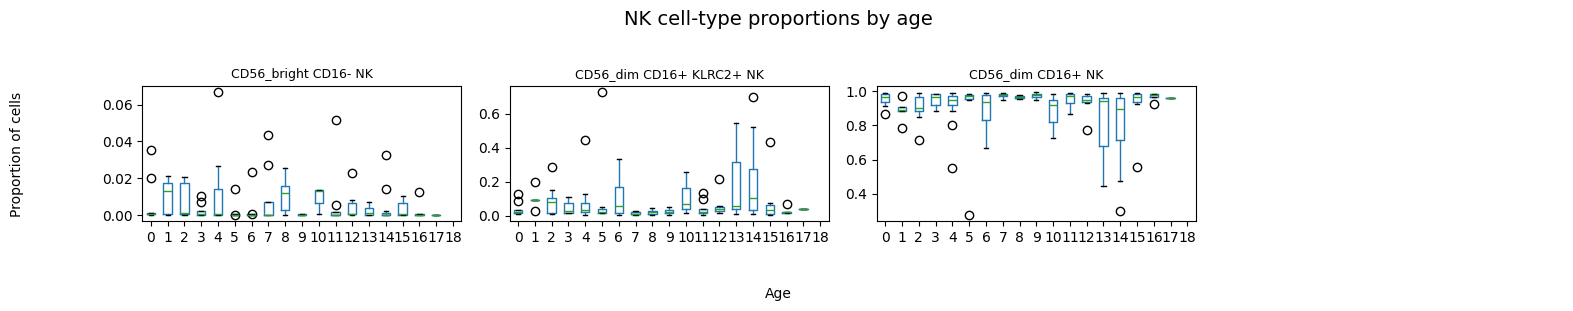

In [31]:
# boxplots of relative abundances per donor per age group
cell_types = sorted(df["pica_cell_type_complete_01_gdT_corrected"].unique())

n_cols = 4
n_rows = math.ceil(len(cell_types) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for ax, cell in zip(axes, cell_types):
    sub = df[df["pica_cell_type_complete_01_gdT_corrected"] == cell]
    sub.boxplot(
        column="Proportion",
        by="Age",
        grid=False,
        ax=ax
    )

    ax.set_xticks(range(1, 20))
    ax.set_xticklabels(range(0, 19))
    ax.set_xlim(0.5, 19.5)
    
    ax.set_title(cell, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

# remove empty panels
for ax in axes[len(cell_types):]:
    ax.axis("off")

plt.suptitle("NK cell-type proportions by age", fontsize=14)
fig.supxlabel("Age", fontsize=10)
fig.supylabel("Proportion of cells", fontsize=10)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()

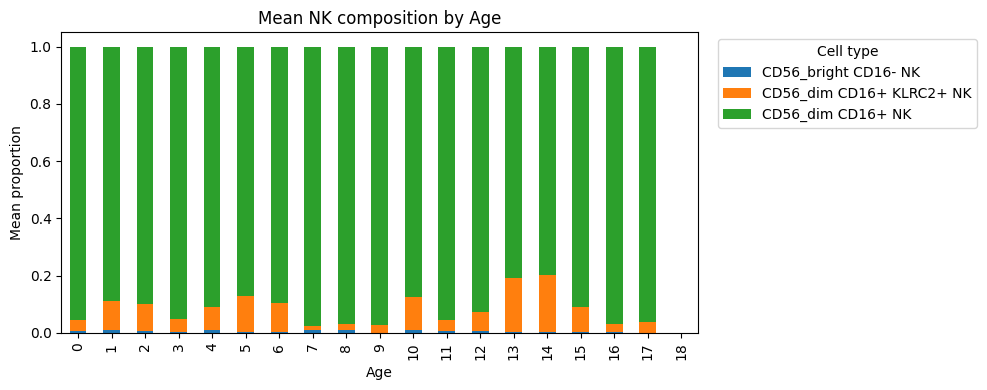

In [32]:
# barplot of composition by age group
props_age = props.join(meta["Age"]).groupby("Age").mean().reindex(range(0, 19))

ax = props_age.plot(kind="bar", stacked=True, figsize=(10, 4))
ax.set_xlabel("Age")
ax.set_ylabel("Mean proportion")
ax.set_title("Mean NK composition by Age")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Cell type")
plt.tight_layout()
plt.show()

In [33]:
# Filter out Batch before plotting
effects_nk_auto_plot = effects_nk_auto[
    ~effects_nk_auto.index.get_level_values("Covariate").str.startswith("Batch")
]

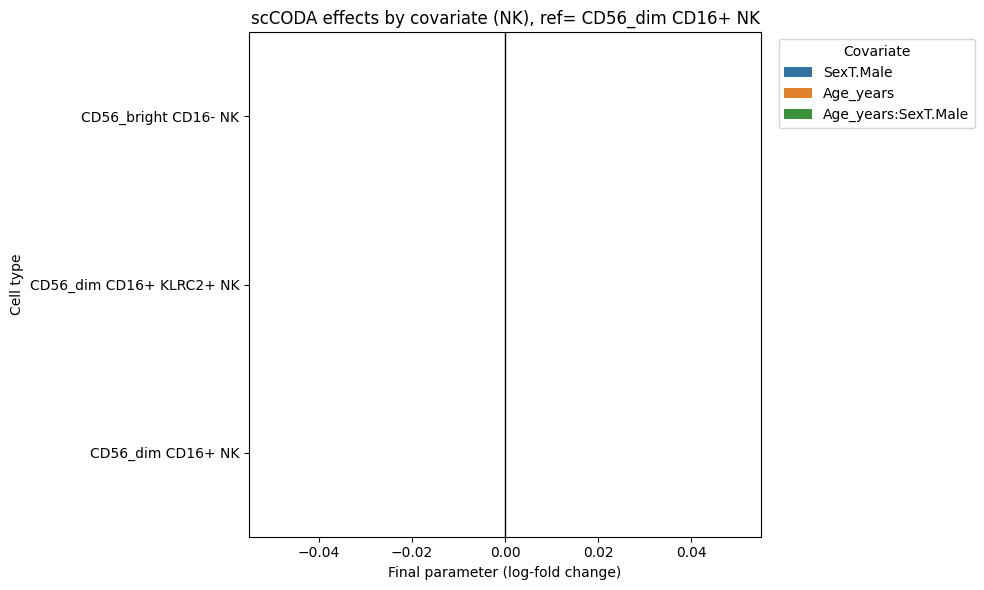

In [34]:
# effect barplot (may need to check your pertpy version)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_nk_auto_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (NK), ref= CD56_dim CD16+ NK")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

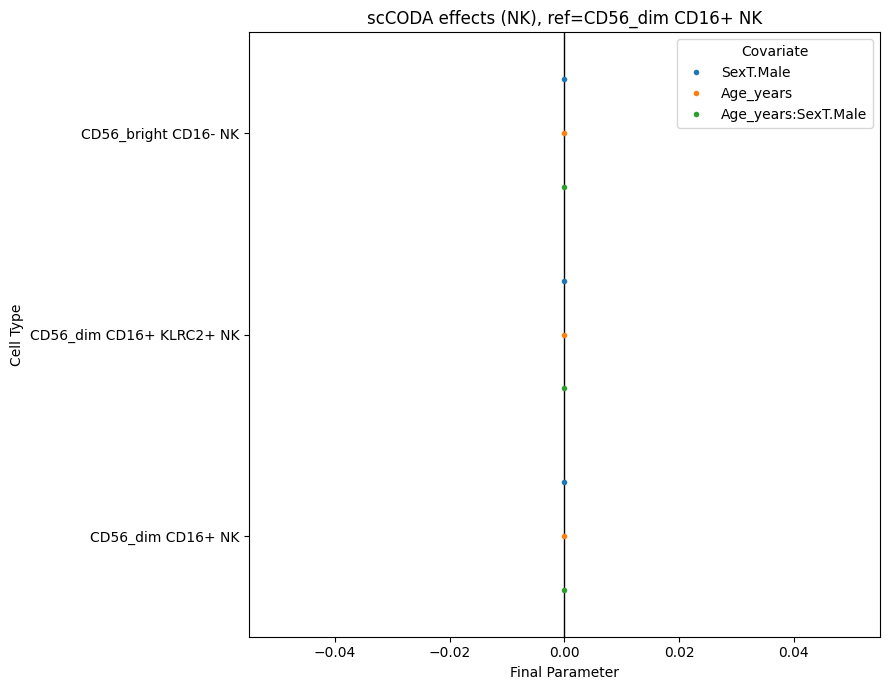

In [35]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_nk_auto_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (NK), ref=CD56_dim CD16+ NK")
plt.tight_layout()
plt.show()

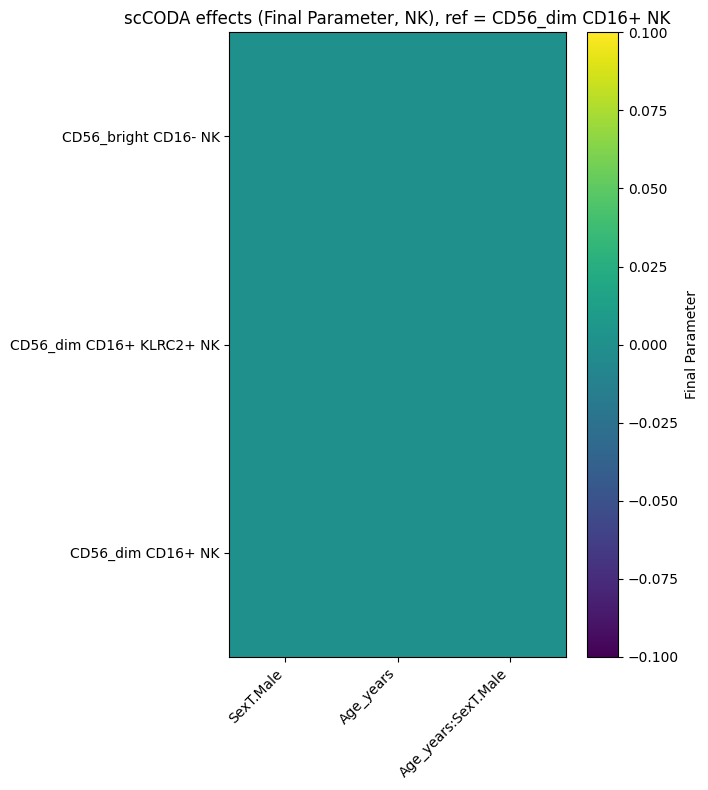

In [36]:
# inclusion pronbability heatmap
tmp_auto = effects_nk_auto_plot.reset_index()
ip_auto = tmp_auto.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta_auto = effects_nk_auto_plot["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta_auto.values, aspect="auto")
plt.yticks(range(beta_auto.shape[0]), beta_auto.index)
plt.xticks(range(beta_auto.shape[1]), beta_auto.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, NK), ref = CD56_dim CD16+ NK")
plt.tight_layout()
plt.show()

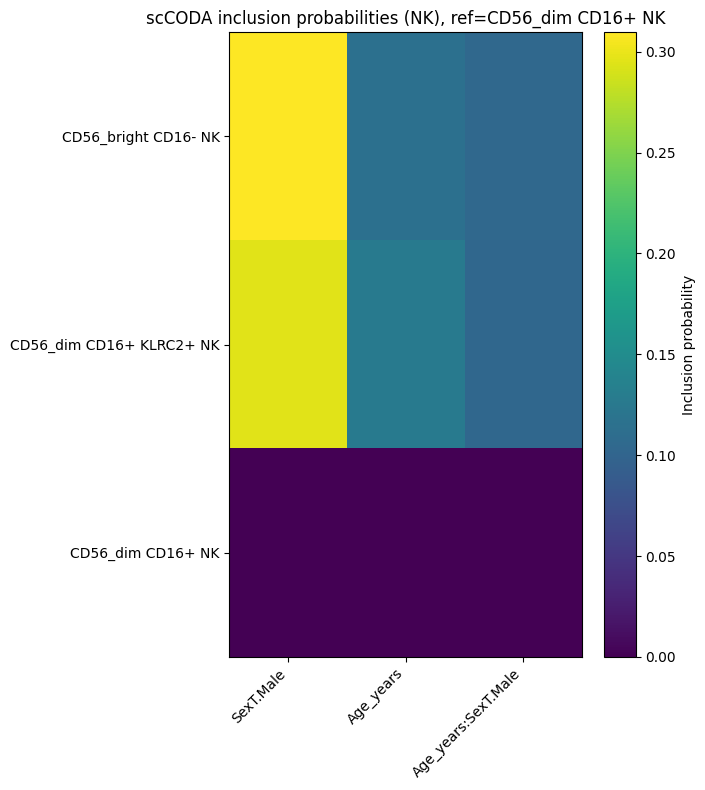

In [37]:
ip_auto = effects_nk_auto_plot["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip_auto.values, aspect="auto")
plt.yticks(range(ip_auto.shape[0]), ip_auto.index)
plt.xticks(range(ip_auto.shape[1]), ip_auto.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (NK), ref=CD56_dim CD16+ NK")
plt.tight_layout()
plt.show()

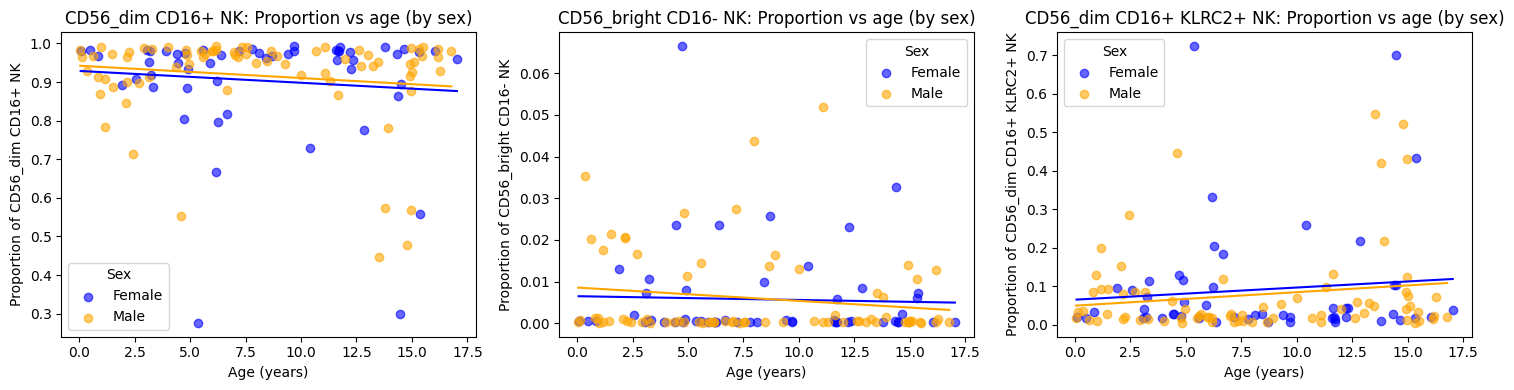

In [45]:
# For each NK cell type
nk_cells = ["CD56_dim CD16+ NK", "CD56_bright CD16- NK", "CD56_dim CD16+ KLRC2+ NK"]

fig, axes = plt.subplots(1, len(nk_cells), figsize=(5*len(nk_cells), 4))

for ax, cell in zip(axes, nk_cells):
    sub = df[df["pica_cell_type_complete_01_gdT_corrected"] == cell]
    for sex, color in zip(["Female", "Male"], ["blue", "orange"]):
        s = sub[sub["Sex"] == sex]
        ax.scatter(s["Age_years"], s["Proportion"], color=color, alpha=0.6, label=sex)
        # add trend line
        import numpy as np
        z = np.polyfit(s["Age_years"], s["Proportion"], 1)
        p = np.poly1d(z)
        ax.plot(sorted(s["Age_years"]), p(sorted(s["Age_years"])), color=color)
    ax.set_title(f"{cell}: Proportion vs age (by sex)")
    ax.set_xlabel("Age (years)")
    ax.set_ylabel(f"Proportion of {cell}")
    ax.legend(title="Sex")

plt.tight_layout()
plt.show()

#### ref cell type model (CD56_bright CD16- NK)

In [21]:
nk_dim = prepare_sccoda_age(sccoda_nk.copy(), ref="CD56_bright CD16- NK")

• Zero counts encountered in data! Added a pseudocount of 0.5.


In [22]:
nk_dim = run_sccoda(nk_dim, rng_key=1)

sample: 100%|██████████| 7000/7000 [04:36<00:00, 25.31it/s, 1023 steps of size 6.76e-03. acc. prob=0.88]


In [23]:
sccoda_model.summary(nk_dim, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 3 cell types                                         │
│ Reference cell type                   │ CD56_bright CD16- NK                                                    │
│ Formula                               │ ~ Age_years * Sex + Batch                                               │
│ Reference index                       │ 0                                                                       │
│ Spike-and-slab threshold              │ 0.939                                                                   │
│ Spike-and-slab threshold              │ 0.939                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 87.8%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                           Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample               │
│ pica_cell_type_complete_01_gdT_corrected                                                                        │
│ CD56_bright CD16- NK                          -1.107       -1.284  -0.922  0.097       10.447                   │
│ CD56_dim CD16+ KLRC2+ NK                       1.069        0.480   1.572  0.284       92.051                   │
│ CD56_dim CD16+ NK                              3.762        3.228   4.320  0.304     1360.139                   │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                               Final Parameter  Expected Sample  log2-fold change                │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD56_bright CD16- NK           0.000            10.447            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            92.051            0.000                     │
│                     CD56_dim CD16+ NK              0.000          1360.139            0.000                     │
│ BatchT.Batch02      CD56_bright CD16- NK           0.000             2.846           -1.876                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            25.072           -1.876                     │
│                     CD56_dim CD16+ NK              1.354          1434.719            0.077                     │
│ BatchT.Batch03      CD56_bright CD16- NK           0.000            48.006            2.200                     │
│                     CD56_dim CD16+ KLRC2+ NK      -0.905           171.053            0.894                     │
│                     CD56_dim CD16+ NK             -1.615          1243.577           -0.129                     │
│ BatchT.Batch04      CD56_bright CD16- NK           0.000             2.087           -2.323                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            18.391           -2.323                     │
│                     CD56_dim CD16+ NK              1.669          1442.159            0.084                     │
│ BatchT.Batch05      CD56_bright CD16- NK           0.000            52.695            2.335                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000           464.300            2.335                     │
│                     CD56_dim CD16+ NK             -1.982           945.642           -0.524                     │
│ BatchT.Batch06      CD56_bright CD16- NK           0.000            10.447            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            92.051            0.000                     │
│                     CD56_dim CD16+ NK              0.000          1360.139            0.000                     │
│ BatchT.Batch07      CD56_bright CD16- NK           0.000            10.937            0.066                     │
│                     CD56_dim CD16+ KLRC2+ NK      -1.244            27.777           -1.729                     │
│                     CD56_dim CD16+ NK              0.000          1423.923            0.066                     │
│ Age_years           CD56_bright CD16- NK           0.000            10.447            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            92.051            0.000                     │
│                     CD56_dim CD16+ NK              0.000          1360.139            0.000                     │
│ Age_years:SexT.Male CD56_bright CD16- NK           0.000            10.447            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            92.051            0.000                     │
│                     CD56_dim CD16+ NK              0.000          1360.139            0.000                     │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                               HDI 3%  HDI 97%   SD   Inclusion probability                      │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD56_bright CD16- NK       0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.231   0.147  0.056         0.280                               │
│                     CD56_dim CD16+ NK         -0.164   0.251  0.061         0.284                               │
│ BatchT.Batch02      CD56_bright CD16- NK       0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.316   1.146  0.325         0.424                               │
│                     CD56_dim CD16+ NK          0.678   2.123  0.369         1.000                               │
│ BatchT.Batch03      CD56_bright CD16- NK       0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ KLRC2+ NK  -1.513  -0.172  0.399         0.940                               │
│                     CD56_dim CD16+ NK         -2.375  -0.842  0.411         0.997                               │
│ BatchT.Batch04      CD56_bright CD16- NK       0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.083   1.383  0.463         0.692                               │
│                     CD56_dim CD16+ NK          0.917   2.531  0.470         1.000                               │
│ BatchT.Batch05      CD56_bright CD16- NK       0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ KLRC2+ NK  -1.215   0.186  0.346         0.431                               │
│                     CD56_dim CD16+ NK         -2.828  -1.273  0.386         1.000                               │
│ BatchT.Batch06      CD56_bright CD16- NK       0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.458   0.415  0.138         0.358                               │
│                     CD56_dim CD16+ NK         -0.305   0.622  0.184         0.405                               │
│ BatchT.Batch07      CD56_bright CD16- NK       0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ KLRC2+ NK  -1.986  -0.490  0.397         0.998                               │
│                     CD56_dim CD16+ NK         -1.357   0.135  0.457         0.642                               │
│ Age_years           CD56_bright CD16- NK       0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.053   0.011  0.007         0.121                               │
│                     CD56_dim CD16+ NK         -0.047   0.019  0.008         0.120                               │
│ Age_years:SexT.Male CD56_bright CD16- NK       0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ KLRC2+ NK  -0.023   0.015  0.004         0.106                               │
│                     CD56_dim CD16+ NK         -0.009   0.039  0.006         0.134                               │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

In [24]:
# set desired FDR globally
sccoda_model.set_fdr(nk_dim, est_fdr=0.1, modality_key="coda")

In [25]:
# check threshold
nk_dim["coda"].uns["scCODA_params"]["threshold_prob"]

np.float64(0.642)

In [26]:
effects_nk_dim = sccoda_model.get_effect_df(nk_dim, modality_key="coda")

effects_nk_dim["Inclusion probability"].max()
effects_nk_dim["Inclusion probability"].describe()

count    27.000000
mean      0.367807
std       0.391519
min       0.000000
25%       0.000000
50%       0.279800
75%       0.666800
max       1.000000
Name: Inclusion probability, dtype: float64

In [27]:

# effects dataframe
effects_nk_dim = sccoda_model.get_effect_df(nk_dim, modality_key="coda")
effects_nk_dim.head()

Final Parameter  HDI 3%  HDI 97%  \
Covariate      Cell Type                                                    
SexT.Male      CD56_bright CD16- NK                  0.0   0.000    0.000   
               CD56_dim CD16+ KLRC2+ NK              0.0  -0.231    0.147   
               CD56_dim CD16+ NK                     0.0  -0.164    0.251   
BatchT.Batch02 CD56_bright CD16- NK                  0.0   0.000    0.000   
               CD56_dim CD16+ KLRC2+ NK              0.0  -0.316    1.146   

                                            SD  Inclusion probability  \
Covariate      Cell Type                                                
SexT.Male      CD56_bright CD16- NK      0.000                 0.0000   
               CD56_dim CD16+ KLRC2+ NK  0.056                 0.2798   
               CD56_dim CD16+ NK         0.061                 0.2844   
BatchT.Batch02 CD56_bright CD16- NK      0.000                 0.0000   
               CD56_dim CD16+ KLRC2+ NK  0.325                 0.4236   

                                         Expected Sample  log2-fold change  
Covariate      Cell Type                                                    
SexT.Male      CD56_bright CD16- NK            10.447282          0.000000  
               CD56_dim CD16+ KLRC2+ NK        92.050913          0.000000  
               CD56_dim CD16+ NK             1360.138524          0.000000  
BatchT.Batch02 CD56_bright CD16- NK             2.845574         -1.876336  
               CD56_dim CD16+ KLRC2+ NK        25.072333         -1.876336

In [28]:
# Filter out Batch before plotting
effects_nk_dim_plot = effects_nk_dim[
    ~effects_nk_dim.index.get_level_values("Covariate").str.startswith("Batch")
]

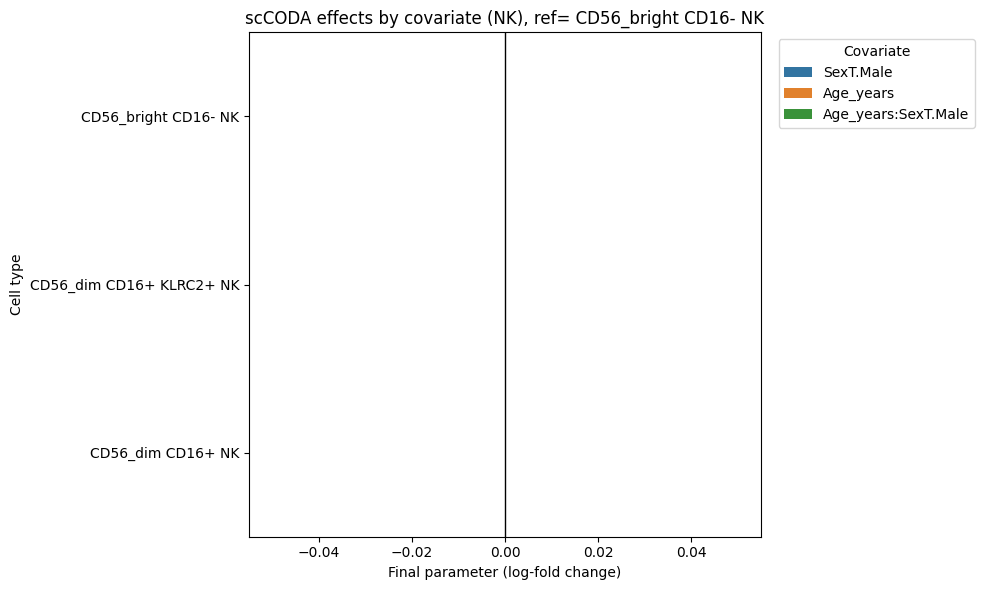

In [29]:
# effect barplot (may need to check your pertpy version)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_nk_dim_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (NK), ref= CD56_bright CD16- NK")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

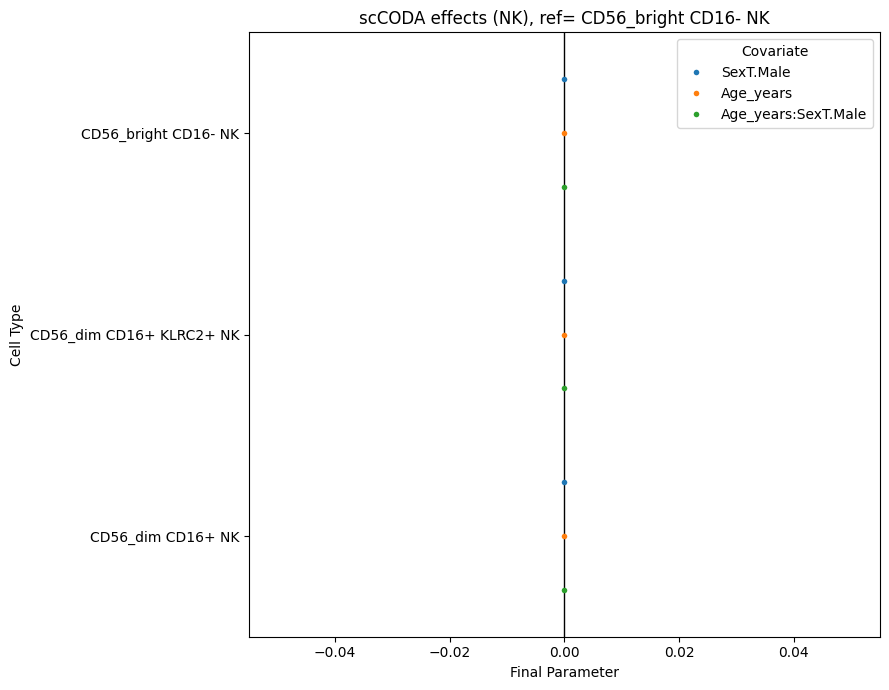

In [30]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_nk_dim_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (NK), ref= CD56_bright CD16- NK")
plt.tight_layout()
plt.show()

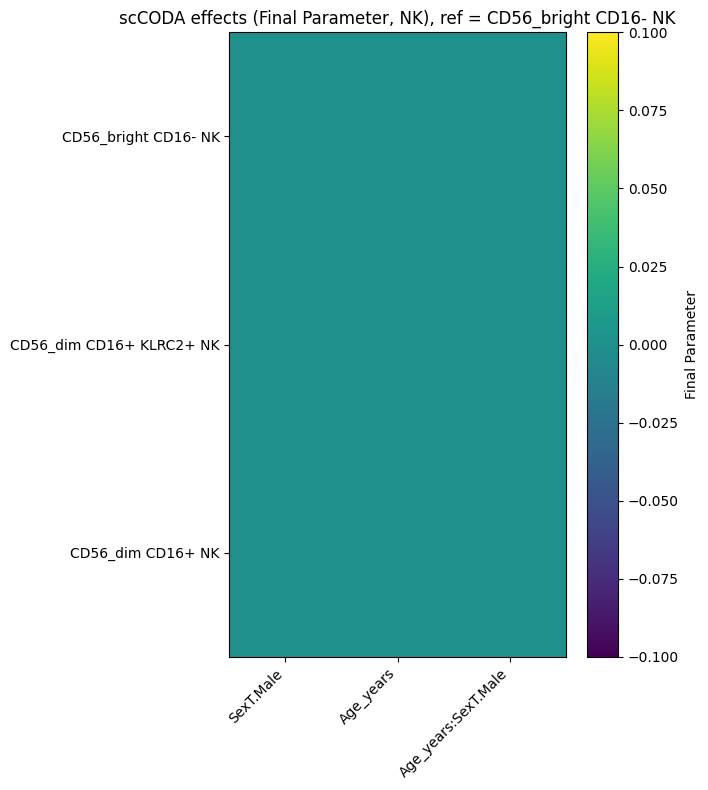

In [31]:
# inclusion pronbability heatmap
tmp_dim = effects_nk_dim_plot.reset_index()
ip_dim = tmp_dim.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta_dim = effects_nk_dim_plot["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta_dim.values, aspect="auto")
plt.yticks(range(beta_dim.shape[0]), beta_dim.index)
plt.xticks(range(beta_dim.shape[1]), beta_dim.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, NK), ref = CD56_bright CD16- NK")
plt.tight_layout()
plt.show()

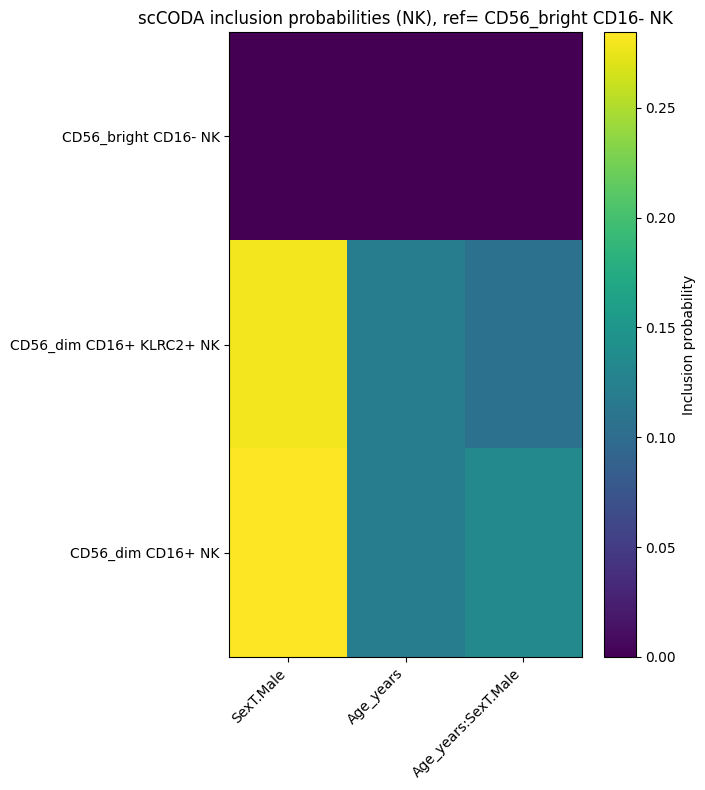

In [32]:
ip_dim = effects_nk_dim_plot["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip_dim.values, aspect="auto")
plt.yticks(range(ip_dim.shape[0]), ip_dim.index)
plt.xticks(range(ip_dim.shape[1]), ip_dim.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (NK), ref= CD56_bright CD16- NK")
plt.tight_layout()
plt.show()

#### ref cell type model (CD56_dim CD16+ KLRC2+ NK)

In [21]:
nk_dim_klrc2 = prepare_sccoda_age(sccoda_nk.copy(), ref="CD56_dim CD16+ KLRC2+ NK")

• Zero counts encountered in data! Added a pseudocount of 0.5.


In [22]:
nk_dim_klrc2 = run_sccoda(nk_dim_klrc2, rng_key=1)

sample: 100%|██████████| 7000/7000 [03:26<00:00, 33.96it/s, 511 steps of size 1.16e-02. acc. prob=0.80] 


In [23]:
sccoda_model.summary(nk_dim_klrc2, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 3 cell types                                         │
│ Reference cell type                   │ CD56_dim CD16+ KLRC2+ NK                                                │
│ Formula                               │ ~ Age_years * Sex + Batch                                               │
│ Reference index                       │ 1                                                                       │
│ Spike-and-slab threshold              │ 0.940                                                                   │
│ Spike-and-slab threshold              │ 0.940                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 79.7%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                           Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample               │
│ pica_cell_type_complete_01_gdT_corrected                                                                        │
│ CD56_bright CD16- NK                          -1.327       -1.671  -0.989  0.182       10.031                   │
│ CD56_dim CD16+ KLRC2+ NK                       0.812        0.614   1.013  0.109       85.173                   │
│ CD56_dim CD16+ NK                              3.588        3.240   3.997  0.208     1367.432                   │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                               Final Parameter  Expected Sample  log2-fold change                │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD56_bright CD16- NK           0.000            10.031            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            85.173            0.000                     │
│                     CD56_dim CD16+ NK              0.000          1367.432            0.000                     │
│ BatchT.Batch02      CD56_bright CD16- NK           0.000             3.387           -1.566                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            28.761           -1.566                     │
│                     CD56_dim CD16+ NK              1.131          1430.488            0.065                     │
│ BatchT.Batch03      CD56_bright CD16- NK           0.716            45.192            2.172                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000           187.522            1.139                     │
│                     CD56_dim CD16+ NK             -0.895          1229.924           -0.153                     │
│ BatchT.Batch04      CD56_bright CD16- NK           0.000             3.328           -1.592                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            28.254           -1.592                     │
│                     CD56_dim CD16+ NK              1.149          1431.056            0.066                     │
│ BatchT.Batch05      CD56_bright CD16- NK           0.000            48.595            2.276                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000           412.619            2.276                     │
│                     CD56_dim CD16+ NK             -1.889          1001.423           -0.449                     │
│ BatchT.Batch06      CD56_bright CD16- NK           0.000            10.031            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            85.173            0.000                     │
│                     CD56_dim CD16+ NK              0.000          1367.432            0.000                     │
│ BatchT.Batch07      CD56_bright CD16- NK           2.484            36.473            1.862                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            25.827           -1.722                     │
│                     CD56_dim CD16+ NK              1.217          1400.336            0.034                     │
│ Age_years           CD56_bright CD16- NK           0.000            10.031            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            85.173            0.000                     │
│                     CD56_dim CD16+ NK              0.000          1367.432            0.000                     │
│ Age_years:SexT.Male CD56_bright CD16- NK           0.000            10.031            0.000                     │
│                     CD56_dim CD16+ KLRC2+ NK       0.000            85.173            0.000                     │
│                     CD56_dim CD16+ NK              0.000          1367.432            0.000                     │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                               HDI 3%  HDI 97%   SD   Inclusion probability                      │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD56_bright CD16- NK      -0.332   0.200  0.080         0.315                               │
│                     CD56_dim CD16+ KLRC2+ NK   0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ NK         -0.224   0.140  0.054         0.294                               │
│ BatchT.Batch02      CD56_bright CD16- NK      -0.444   0.576  0.145         0.286                               │
│                     CD56_dim CD16+ KLRC2+ NK   0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ NK          0.675   1.590  0.232         1.000                               │
│ BatchT.Batch03      CD56_bright CD16- NK       0.204   1.211  0.298         0.941                               │
│                     CD56_dim CD16+ KLRC2+ NK   0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ NK         -1.299  -0.459  0.229         0.991                               │
│ BatchT.Batch04      CD56_bright CD16- NK      -0.380   0.630  0.154         0.288                               │
│                     CD56_dim CD16+ KLRC2+ NK   0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ NK          0.682   1.561  0.226         1.000                               │
│ BatchT.Batch05      CD56_bright CD16- NK      -1.070   0.045  0.355         0.549                               │
│                     CD56_dim CD16+ KLRC2+ NK   0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ NK         -2.388  -1.393  0.257         1.000                               │
│ BatchT.Batch06      CD56_bright CD16- NK      -0.593   0.252  0.149         0.392                               │
│                     CD56_dim CD16+ KLRC2+ NK   0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ NK         -0.375   0.491  0.144         0.387                               │
│ BatchT.Batch07      CD56_bright CD16- NK       1.935   3.016  0.275         1.000                               │
│                     CD56_dim CD16+ KLRC2+ NK   0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ NK          0.676   1.665  0.244         1.000                               │
│ Age_years           CD56_bright CD16- NK      -0.031   0.019  0.006         0.121                               │
│                     CD56_dim CD16+ KLRC2+ NK   0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ NK         -0.024   0.009  0.003         0.087                               │
│ Age_years:SexT.Male CD56_bright CD16- NK      -0.031   0.012  0.006         0.117                               │
│                     CD56_dim CD16+ KLRC2+ NK   0.000   0.000  0.000         0.000                               │
│                     CD56_dim CD16+ NK         -0.016   0.013  0.002         0.073                               │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

In [24]:
# set desired FDR globally
sccoda_model.set_fdr(nk_dim_klrc2, est_fdr=0.1, modality_key="coda")

In [25]:
# check threshold
nk_dim_klrc2["coda"].uns["scCODA_params"]["threshold_prob"]

np.float64(0.548)

In [26]:
effects_nk_dim_klrc2 = sccoda_model.get_effect_df(nk_dim_klrc2, modality_key="coda")

effects_nk_dim_klrc2["Inclusion probability"].max()
effects_nk_dim_klrc2["Inclusion probability"].describe()

count    27.000000
mean      0.364504
std       0.405558
min       0.000000
25%       0.000000
50%       0.286200
75%       0.744600
max       1.000000
Name: Inclusion probability, dtype: float64

In [27]:

# effects dataframe
effects_nk_dim_klrc2 = sccoda_model.get_effect_df(nk_dim_klrc2, modality_key="coda")
effects_nk_dim_klrc2.head()

Final Parameter  HDI 3%  HDI 97%  \
Covariate      Cell Type                                                    
SexT.Male      CD56_bright CD16- NK                  0.0  -0.332    0.200   
               CD56_dim CD16+ KLRC2+ NK              0.0   0.000    0.000   
               CD56_dim CD16+ NK                     0.0  -0.224    0.140   
BatchT.Batch02 CD56_bright CD16- NK                  0.0  -0.444    0.576   
               CD56_dim CD16+ KLRC2+ NK              0.0   0.000    0.000   

                                            SD  Inclusion probability  \
Covariate      Cell Type                                                
SexT.Male      CD56_bright CD16- NK      0.080                 0.3152   
               CD56_dim CD16+ KLRC2+ NK  0.000                 0.0000   
               CD56_dim CD16+ NK         0.054                 0.2938   
BatchT.Batch02 CD56_bright CD16- NK      0.145                 0.2862   
               CD56_dim CD16+ KLRC2+ NK  0.000                 0.0000   

                                         Expected Sample  log2-fold change  
Covariate      Cell Type                                                    
SexT.Male      CD56_bright CD16- NK            10.031097          0.000000  
               CD56_dim CD16+ KLRC2+ NK        85.173463          0.000000  
               CD56_dim CD16+ NK             1367.432159          0.000000  
BatchT.Batch02 CD56_bright CD16- NK             3.387312         -1.566267  
               CD56_dim CD16+ KLRC2+ NK        28.761469         -1.566267

In [28]:
# Filter out Batch before plotting
effects_nk_dim_klrc2_plot = effects_nk_dim_klrc2[
    ~effects_nk_dim_klrc2.index.get_level_values("Covariate").str.startswith("Batch")
]

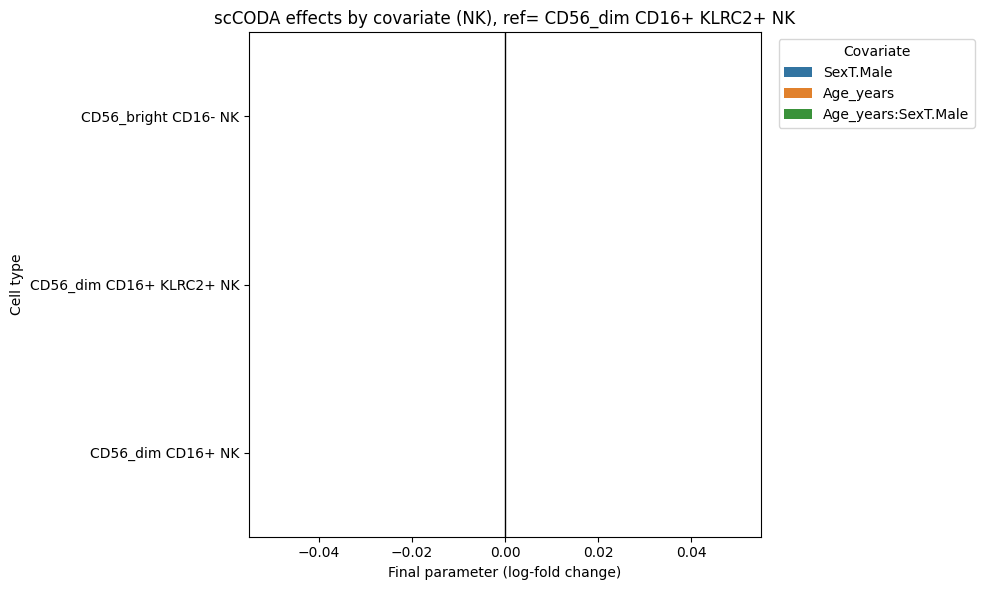

In [29]:
# effect barplot (may need to check your pertpy version)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_nk_dim_klrc2_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (NK), ref= CD56_dim CD16+ KLRC2+ NK")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

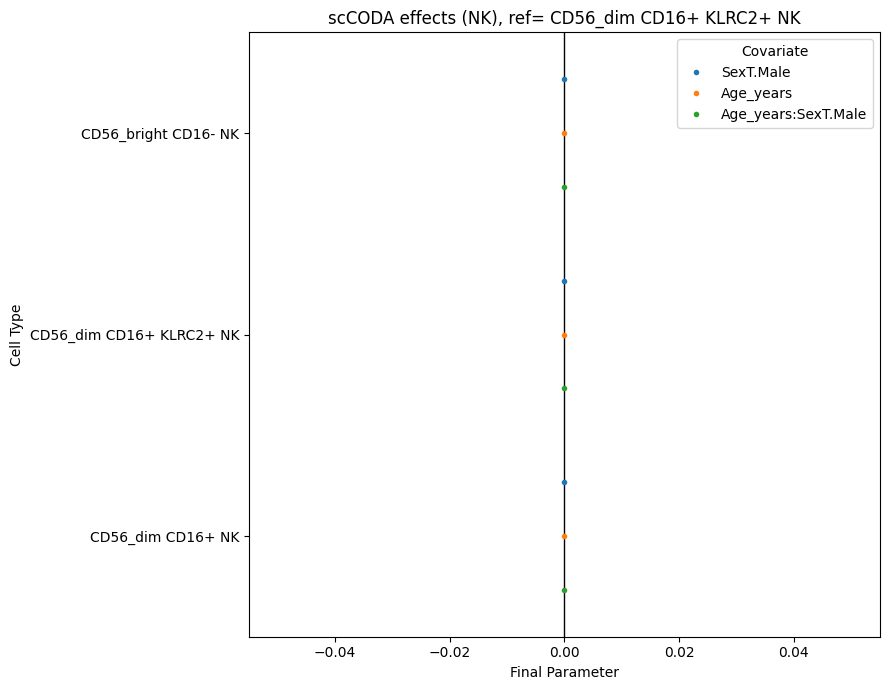

In [30]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_nk_dim_klrc2_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (NK), ref= CD56_dim CD16+ KLRC2+ NK")
plt.tight_layout()
plt.show()

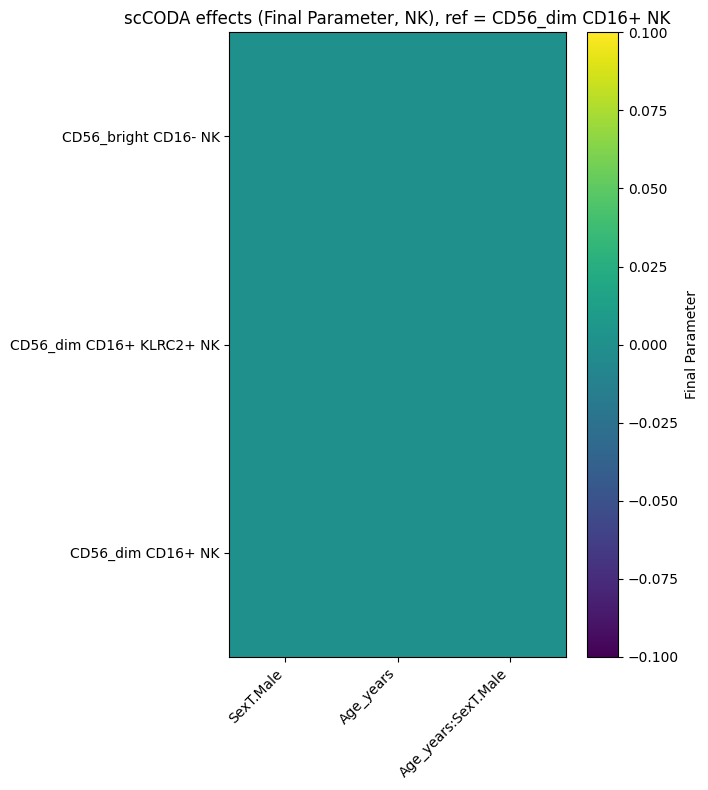

In [31]:
# inclusion pronbability heatmap
tmp_dim_klrc2 = effects_nk_dim_klrc2_plot.reset_index()
ip_dim_klrc2 = tmp_dim_klrc2.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta_dim_klrc2 = effects_nk_dim_klrc2_plot["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta_dim_klrc2.values, aspect="auto")
plt.yticks(range(beta_dim_klrc2.shape[0]), beta_dim_klrc2.index)
plt.xticks(range(beta_dim_klrc2.shape[1]), beta_dim_klrc2.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, NK), ref = CD56_dim CD16+ NK")
plt.tight_layout()
plt.show()

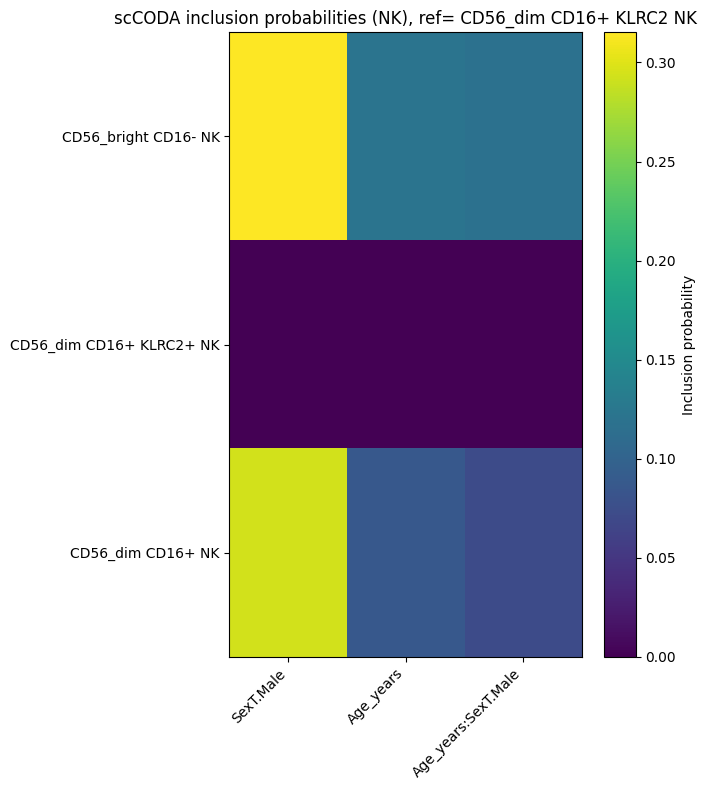

In [32]:
ip_dim_klrc2 = effects_nk_dim_klrc2_plot["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip_dim_klrc2.values, aspect="auto")
plt.yticks(range(ip_dim_klrc2.shape[0]), ip_dim_klrc2.index)
plt.xticks(range(ip_dim_klrc2.shape[1]), ip_dim_klrc2.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (NK), ref= CD56_dim CD16+ KLRC2 NK")
plt.tight_layout()
plt.show()